## 🌲 Isolation Forest Anomaly Detection

## ☁️ One-Class SVM Anomaly Detection

### 🔍 Anomaly Detection Summary

,Method,Anomalies Detected
0,Isolation Forest,50
1,One-Class SVM,59


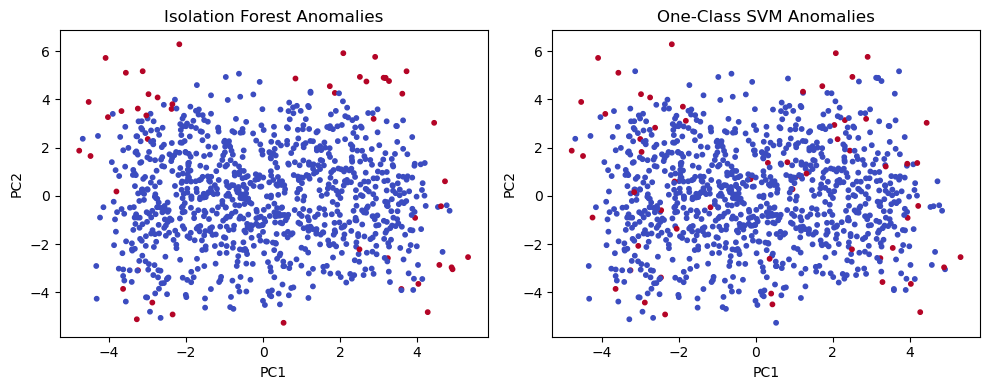

✅ Anomaly detection results saved to ../data/processed/customer_anomaly_labeled.csv


### 🤖 Automated Interpretation of Anomaly Detection Results:


- **Isolation Forest** flagged **50** customers as anomalies (**5.00%** of total).
  - These customers exhibit unusual behavior compared to the rest of the population.
  - They may warrant further analysis, such as fraud investigation or special targeting.



- **One-Class SVM** flagged **59** customers as anomalies (**5.90%** of total).
  - These customers exhibit unusual behavior compared to the rest of the population.
  - They may warrant further analysis, such as fraud investigation or special targeting.


## 📦 Anomaly Detection on Transaction Data

,Method,Anomalies Detected
0,Isolation Forest (Txn),50
1,One-Class SVM (Txn),50


✅ Transaction anomaly detection saved to ../data/processed/transaction_anomaly_labeled.csv


### 🤖 Automated Interpretation of Transaction Anomalies:


- **Isolation Forest (Txn)** flagged **50** customer transaction profiles as anomalies (**5.00%** of total).
  - These customers had unusual purchase patterns such as extreme amounts, frequency, or category diversity.
  - These outliers might indicate fraud, high-value behaviors, or data quality issues.



- **One-Class SVM (Txn)** flagged **50** customer transaction profiles as anomalies (**5.00%** of total).
  - These customers had unusual purchase patterns such as extreme amounts, frequency, or category diversity.
  - These outliers might indicate fraud, high-value behaviors, or data quality issues.


In [ ]:
# Step 6: Anomaly Detection - Isolation Forest and One-Class SVM

from IPython.display import display, Markdown
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load the main customer profile data
customer_df = pd.read_csv("../data/retail_customer_data.csv")

# Select only numeric features for anomaly detection
numeric_cols = customer_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
X = customer_df[numeric_cols].dropna()

# Normalize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Isolation Forest ---
display(Markdown("## 🌲 Isolation Forest Anomaly Detection"))
iso_model = IsolationForest(contamination=0.05, random_state=42)
iso_preds = iso_model.fit_predict(X_scaled)
customer_df['anomaly_iso'] = iso_preds

# --- One-Class SVM ---
display(Markdown("## ☁️ One-Class SVM Anomaly Detection"))
svm_model = OneClassSVM(nu=0.05, kernel="rbf", gamma='auto')
svm_preds = svm_model.fit_predict(X_scaled)
customer_df['anomaly_svm'] = svm_preds

# --- Compare and Visualize ---
display(Markdown("### 🔍 Anomaly Detection Summary"))
anomaly_summary = pd.DataFrame({
    "Method": ["Isolation Forest", "One-Class SVM"],
    "Anomalies Detected": [sum(iso_preds == -1), sum(svm_preds == -1)]
})
display(anomaly_summary)

# PCA 2D projection for visualization
pca_2d = PCA(n_components=2).fit_transform(X_scaled)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(pca_2d[:, 0], pca_2d[:, 1], c=(iso_preds == -1), cmap='coolwarm', s=10)
plt.title("Isolation Forest Anomalies")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.subplot(1, 2, 2)
plt.scatter(pca_2d[:, 0], pca_2d[:, 1], c=(svm_preds == -1), cmap='coolwarm', s=10)
plt.title("One-Class SVM Anomalies")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.tight_layout()
plt.show()

# Save anomaly-labeled dataset
customer_df.to_csv("../data/processed/customer_anomaly_labeled.csv", index=False)
print("✅ Anomaly detection results saved to ../data/processed/customer_anomaly_labeled.csv")

# --- Automated Interpretation ---
if not anomaly_summary.empty:
    display(Markdown("### 🤖 Automated Interpretation of Anomaly Detection Results:"))
    for idx, row in anomaly_summary.iterrows():
        method = row['Method']
        count = row['Anomalies Detected']
        total = len(customer_df)
        pct = (count / total) * 100
        display(Markdown(f"""
- **{method}** flagged **{count}** customers as anomalies (**{pct:.2f}%** of total).
  - These customers exhibit unusual behavior compared to the rest of the population.
  - They may warrant further analysis, such as fraud investigation or special targeting.
"""))
else:
    display(Markdown("**No anomalies were detected using the configured models.**"))

# --- Apply anomaly detection to transaction-level data ---
display(Markdown("## 📦 Anomaly Detection on Transaction Data"))

# Load transaction data
transactions_df = pd.read_csv("../data/customer_transactions.csv")

# Create transaction-level summary per customer
txn_summary = transactions_df.groupby('customer_id').agg({
    'transaction_id': 'nunique',
    'transaction_amount': ['sum', 'mean', 'max', 'min'],
    'item_category': 'nunique'
})
txn_summary.columns = ['_'.join(col) for col in txn_summary.columns]
txn_summary = txn_summary.reset_index()

# Normalize
txn_scaled = StandardScaler().fit_transform(txn_summary.drop(columns='customer_id'))

# Apply Isolation Forest and One-Class SVM
iso_txn = IsolationForest(contamination=0.05, random_state=42)
txn_summary['anomaly_iso_txn'] = iso_txn.fit_predict(txn_scaled)

svm_txn = OneClassSVM(nu=0.05, kernel='rbf', gamma='auto')
txn_summary['anomaly_svm_txn'] = svm_txn.fit_predict(txn_scaled)

# Summary
txn_anomaly_summary = pd.DataFrame({
    "Method": ["Isolation Forest (Txn)", "One-Class SVM (Txn)"],
    "Anomalies Detected": [sum(txn_summary['anomaly_iso_txn'] == -1), sum(txn_summary['anomaly_svm_txn'] == -1)]
})
display(txn_anomaly_summary)

# Save transaction-level anomaly detection
txn_summary.to_csv("../data/processed/transaction_anomaly_labeled.csv", index=False)
print("✅ Transaction anomaly detection saved to ../data/processed/transaction_anomaly_labeled.csv")

# --- Automated Interpretation of Transaction-Level Anomalies ---
if not txn_anomaly_summary.empty:
    display(Markdown("### Interpretation of Transaction Anomalies:"))
    for idx, row in txn_anomaly_summary.iterrows():
        method = row['Method']
        count = row['Anomalies Detected']
        total = len(txn_summary)
        pct = (count / total) * 100
        display(Markdown(f"""
- **{method}** flagged **{count}** customer transaction profiles as anomalies (**{pct:.2f}%** of total).
  - These customers had unusual purchase patterns such as extreme amounts, frequency, or category diversity.
  - These outliers might indicate fraud, high-value behaviors, or data quality issues.
"""))
else:
    display(Markdown("**No transaction anomalies were detected using the configured models.**"))
